In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import matplotlib.patches as patches
#from mpl_toolkits.mplot3d import Axes3D
#from pylab import *

In [2]:
cohort = [
    #LS1
    "1_AlDe",
    "2_ReDo",
    "3_JuRo",
    "4_MaPo",
    "5_MaGo",
    "6_ElHa",
    #LS2
    "7_KlMe",
    "8_JuUe",
    "9_PhBa",
    "10_ToBa",
    "11_SePe",
    "12_ViDi",
    #LS3
    "13_FaPu",
    "14_JeBi",
    "15_DaEi",
    "16_MaEg",
    "17_JaDe",
    "18_InHo",
    #LS4
    "19_ToGr",
    "20_PeBu",
    "21_HaPr",
    "22_ClSt",
    "23_DaMe",
    "24_JoHi",
    #LS5
    "25_LeSc",
    "26_BaBa",
    "27_KaHi",
    "28_JoSc",
    "29_JeHo",
    "30_LiPa",
    #LS6
    "31_GiDe",
    "32_AnRa",
    "33_MaSu",
    "34_MiDo",
    "35_FlRu",
    "36_FaAs",
    #LS7
    "37_SiMi",
    "38_FaUe",
    ]

In [3]:
shovel = "Shovel"
cube = "Cube"

c_0 = "C0"
c_1 = "C1"
c_2 = "C2"
p_0 = "P0"
p_1 = "P1"
p_2 = "P2"

conditions = [c_0, c_1, c_2, p_0, p_1, p_2]

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

unity = "u"
imot = "i"

start_ts = "start"
end_ts = "end"

rhr = "resting_hr"

unity_unix_key = "ts_unix_ms"

unified_delta_key = "delta_ms"
unified_unix_key = "unix_ms"

imot_unix_key = "System Timestamp CAL"
imot_delta_ms_key = "Timestamp"
hr_key = 'Heart rate'
gsr_key = 'GSR Resistance CAL'
gsc_key = 'GSR Conductance CAL'

imot_keys = [imot_unix_key, imot_delta_ms_key, hr_key, gsr_key, gsc_key]

In [4]:
def get_df(p, e, c, s):
    path = './data/' + p + '/'  + s  + '_' + e + '_' + c + '.csv'
    return pd.read_csv(path)

def task_start(df, e):
    if e == cube:
        return df[unity_unix_key].min()
    else:
        first_load = df[(df["collision_or_load_count"] == 1)]
        return first_load[unity_unix_key].min()

def task_end(df, e):
    if e == cube:
        return df[unity_unix_key].max()
    else:
        final_load = df[(df["collision_or_load_count"] == 20)]
        final_unload = final_load[(final_load["shovel_loaded_state"] == False)]

        return final_unload[unity_unix_key].min()
    
def trim_df(df, min_ts, max_ts):
    min_trimmed = df[(df[unified_unix_key] >= min_ts)]
    full_trimmed = min_trimmed[(min_trimmed[unified_unix_key] <= max_ts)]
    return full_trimmed

def sync_timestamps(unity_df, imot_df, e):
    task_start_ts = task_start(unity_df, e)

    unity_df[unified_unix_key] = unity_df[unity_unix_key]
    unity_df[unified_delta_key] = unity_df[unified_unix_key] - task_start_ts

    imot_start = imot_df.dropna(subset = imot_unix_key).iloc[0][imot_unix_key]

    imot_df[unified_unix_key] = imot_start + imot_df[imot_delta_ms_key]
    imot_df[unified_delta_key] = imot_df[unified_unix_key] - task_start_ts

    return [unity_df, imot_df]

def get_condition(p, e, c):
    imot_raw = get_df(p, e, c, imot).filter(items=imot_keys)
    unity_raw = get_df(p, e, c, unity)

    synced = sync_timestamps(unity_raw, imot_raw, e)
    unity_synced = synced[0]
    imot_synced = synced[1]

    task_start_ts = task_start(unity_raw, e)
    task_end_ts = task_end(unity_raw, e)

    return {
        imot: imot_synced,
        unity: unity_synced,
        start_ts: task_start_ts,
        end_ts: task_end_ts
    }

def get_experiment(p, e):
    return {
            c_0: get_condition(p, e, c_0),
            c_1: get_condition(p, e, c_1),
            c_2: get_condition(p, e, c_2),
            p_0: get_condition(p, e, p_0),
            p_1: get_condition(p, e, p_1),
            p_2: get_condition(p, e, p_2),
        }

def get_participant(p):
    return {
        cube: get_experiment(p, cube),
        shovel: get_experiment(p, shovel)
    }

In [5]:
data = list(map(lambda x: get_participant(x), cohort))

In [6]:
data[0][shovel][c_0][unity].head(3)

,ts_datetime,ts_unix_ms,primary_grab_hand,pt_x,pt_y,pt_z,st_x,st_y,st_z,pv_x,...,hmd_z,ee_x,ee_y,ee_z,shovel_loaded_state,cube_max_target_reached,grab_count,collision_or_load_count,unix_ms,delta_ms
0,6/17/2025 12:47:46 PM,1750157266336,Right,0.013479,0.082617,0.009835,-0.026263,0.161040,0.275415,0.013534,...,0.109002,-0.000339,0.069995,0.740010,False,0,1,0,1750157266336,-7097
1,6/17/2025 12:47:46 PM,1750157266350,Right,0.013560,0.082527,0.009633,-0.025655,0.159465,0.275159,0.013639,...,0.108624,-0.109571,0.213849,0.729117,False,0,1,0,1750157266350,-7083
2,6/17/2025 12:47:46 PM,1750157266379,Right,0.013584,0.082218,0.009236,-0.025412,0.157989,0.274887,0.013584,...,0.107817,-0.109463,0.209042,0.729566,False,0,1,0,1750157266379,-7054


In [7]:
max_z_score = 3

baseline_ms = 30_000

def remove_outliers(df, key):
    cleaned = df.dropna(subset = key)
    return cleaned
    smoothed = cleaned[np.abs(stats.zscore(cleaned[key])) < max_z_score]
    return smoothed

def single_median(df, key):
    return remove_outliers(df, key)[key].median()

def pre_mean_delta(p, key):
    start = p[start_ts]
    end = p[end_ts]

    start = trim_df(p[imot], min_ts = start - 10_000, max_ts = start)
    end = trim_df(p[imot], min_ts = end - 10_000, max_ts = end + 10_000)

    return (remove_outliers(end, key)[key].median() - remove_outliers(start, key)[key].median())

def plot_experiments(cube_values, shovel_values, title, ylabel):
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))

    labels = conditions

    cube_means = list(map(lambda x: np.mean(x), cube_values))
    axs[0,0].bar(labels, cube_means, color=colors)
    axs[0,0].set_title('[Cube] Mean' + title)
    axs[0,0].set_ylabel(ylabel)

    axs[1,0].boxplot(cube_values, tick_labels=labels)
    axs[1,0].set_title('[Cube] ' + title)
    axs[1,0].set_ylabel(ylabel)

    shovel_means = list(map(lambda x: np.mean(x), shovel_values))
    axs[0,1].bar(labels, shovel_means, color=colors)
    axs[0,1].set_title('[Shovel] Mean' + title)
    axs[0,1].set_ylabel(ylabel)

    axs[1,1].boxplot(shovel_values, tick_labels=labels)
    axs[1,1].set_title('[Shovel] ' + title)
    axs[1,1].set_ylabel(ylabel)

    plt.show()

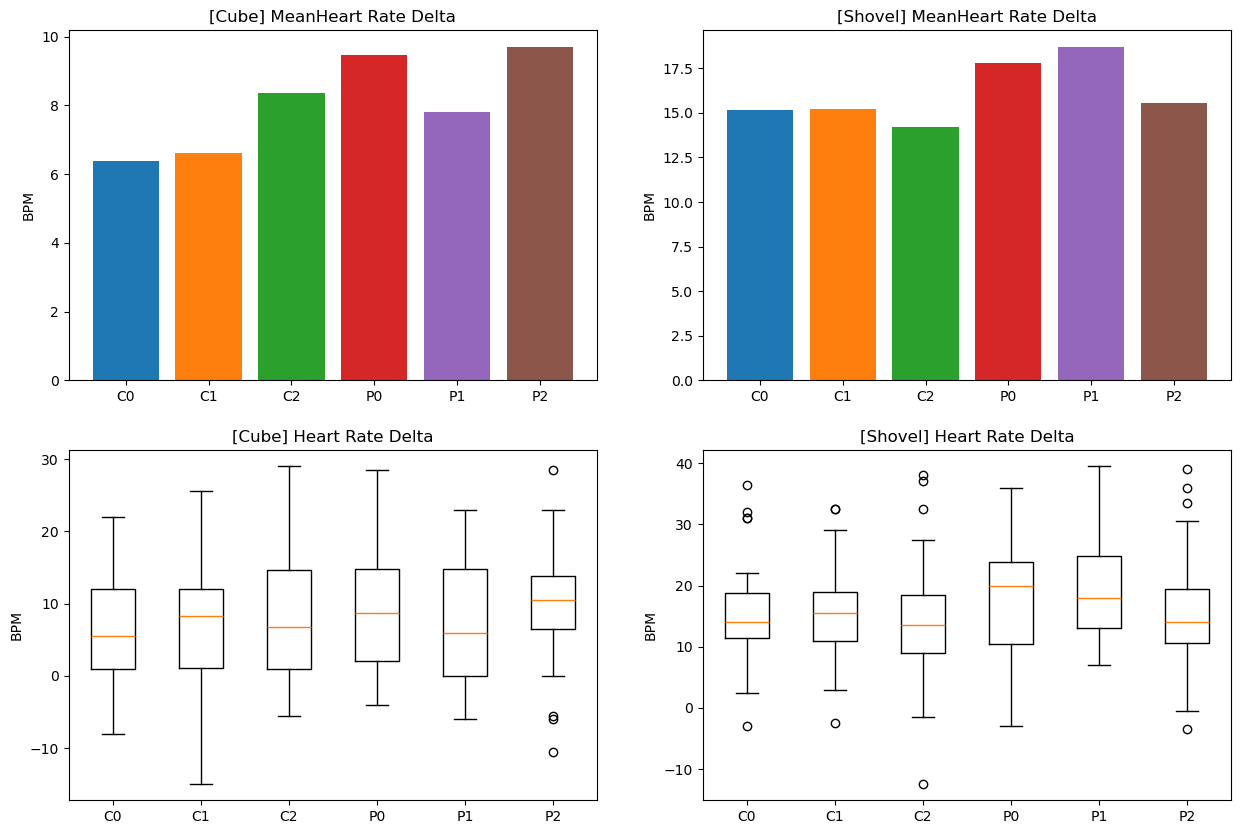

In [8]:
def agg_hr(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(lambda x: pre_mean_delta(x, hr_key), participants))
    return single_values

labels = conditions
cube_values = list(map(lambda x: agg_hr(data, cube, x), conditions))
shovel_values = list(map(lambda x: agg_hr(data, shovel, x), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'Heart Rate Delta',
    ylabel= 'BPM'
    )

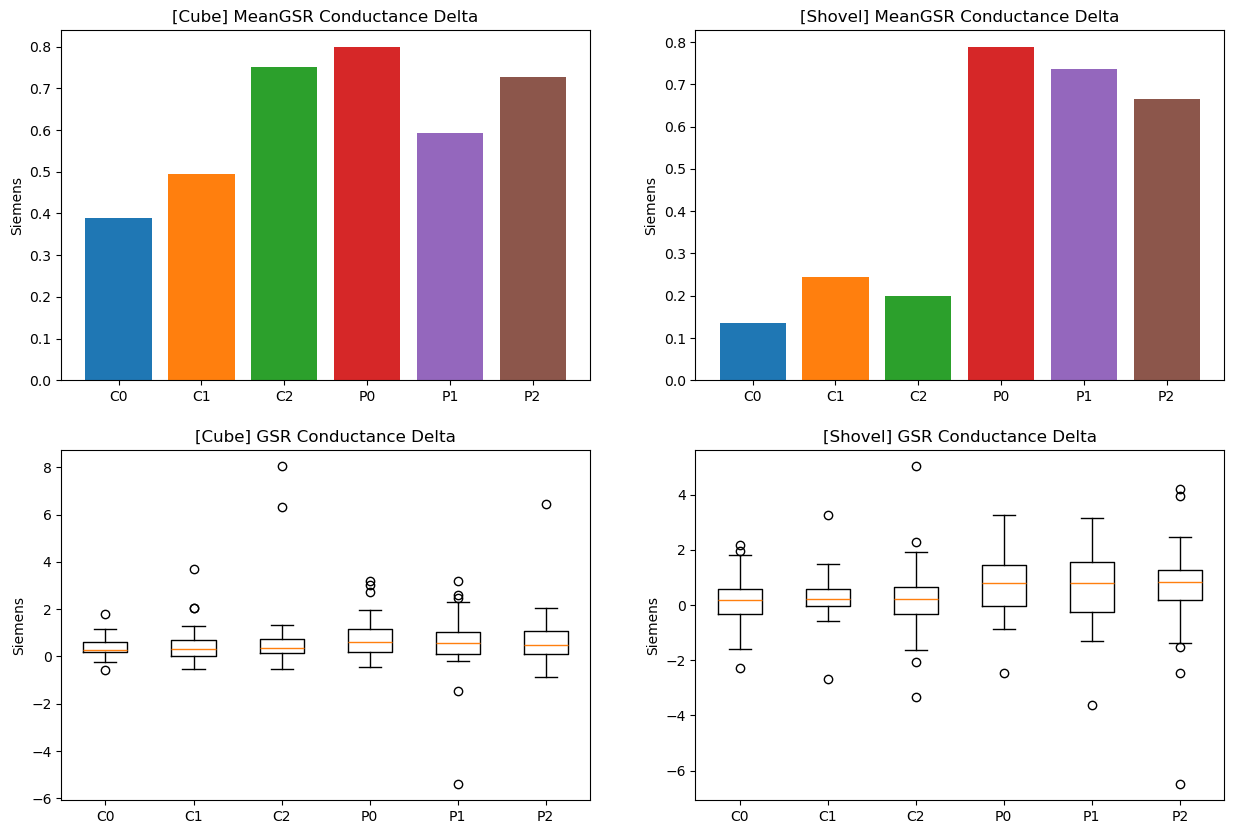

In [9]:
def agg_gsc(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(lambda x: pre_mean_delta(x, gsc_key), participants))
    return single_values

cube_values = list(map(lambda x: agg_gsc(data, cube, x), conditions))
shovel_values = list(map(lambda x: agg_gsc(data, shovel, x), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'GSR Conductance Delta',
    ylabel= 'Siemens'
    )

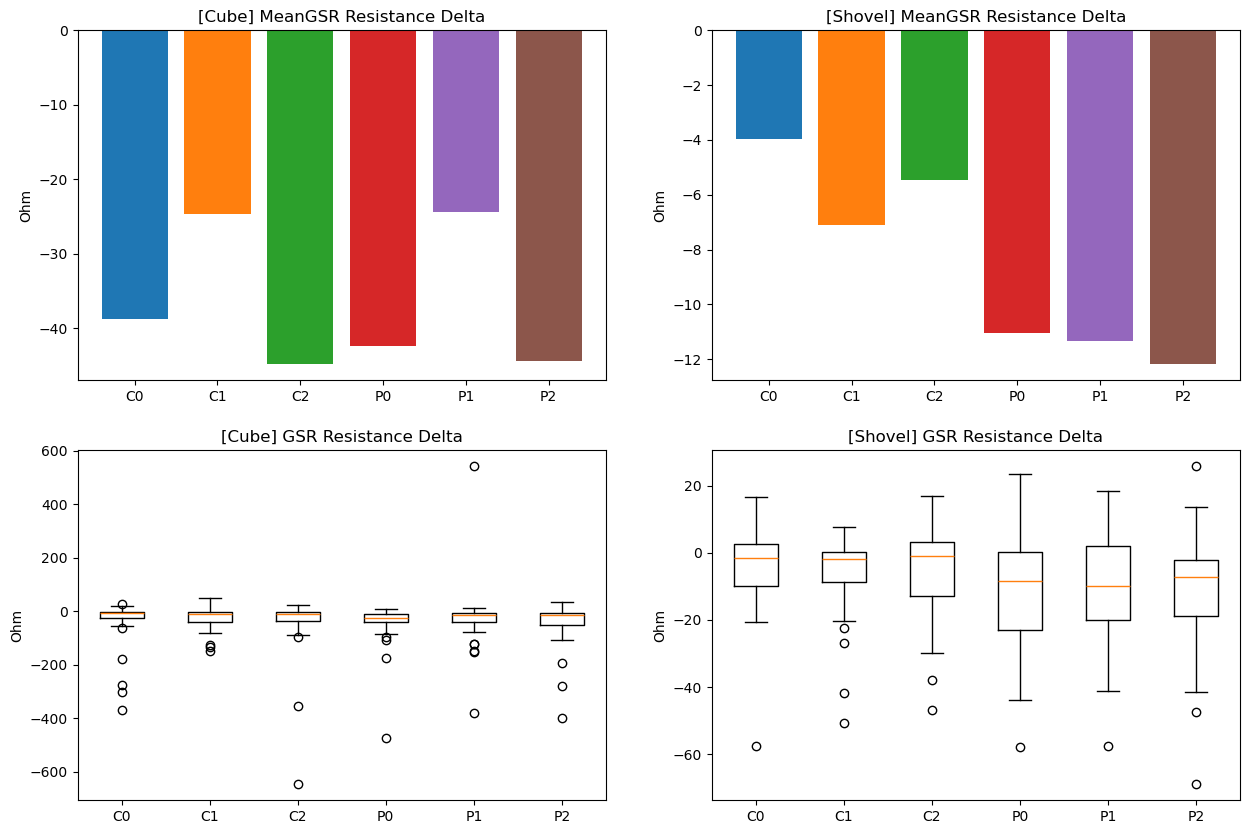

In [10]:
def agg_gsr(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(lambda x: pre_mean_delta(x, gsr_key), participants))
    return single_values

cube_values = list(map(lambda x: agg_gsr(data, cube, x), conditions))
shovel_values = list(map(lambda x: agg_gsr(data, shovel, x), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'GSR Resistance Delta',
    ylabel= 'Ohm'
    )

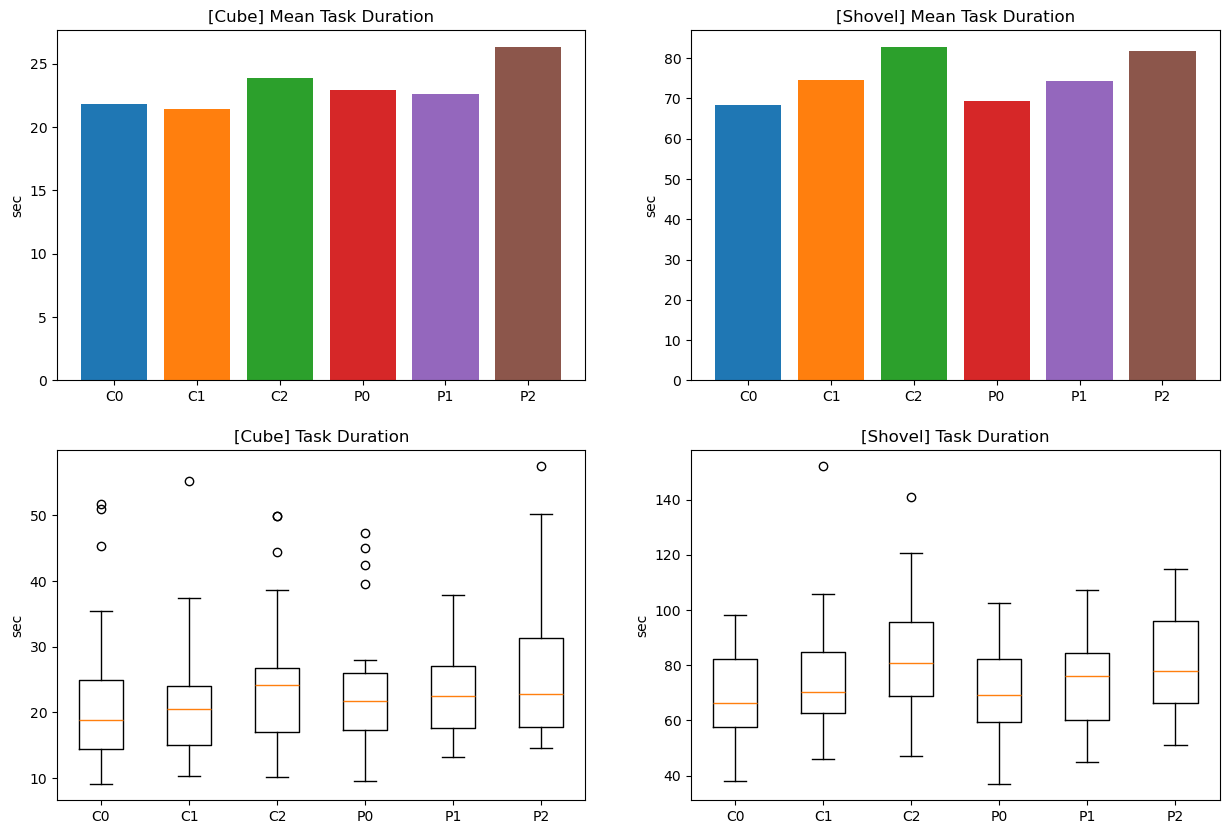

In [11]:
def single_duration(p):
    return (p[end_ts] - p[start_ts]) / 1_000

def agg_duration(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(single_duration, participants))
    return single_values

cube_values = list(map(lambda x: agg_duration(data, cube, x), conditions))
shovel_values = list(map(lambda x: agg_duration(data, shovel, x), conditions))

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

labels = conditions

cube_means = list(map(lambda x: np.mean(x), cube_values))
axs[0,0].bar(labels, cube_means, color=colors)
axs[0,0].set_title('[Cube] ' + 'Mean Task Duration')
axs[0,0].set_ylabel('sec')

axs[1,0].boxplot(cube_values, tick_labels=labels)
axs[1,0].set_title('[Cube] ' + 'Task Duration')
axs[1,0].set_ylabel('sec')

shovel_means = list(map(lambda x: np.mean(x), shovel_values))
axs[0,1].bar(labels, shovel_means, color=colors)
axs[0,1].set_title('[Shovel] ' + 'Mean Task Duration')
axs[0,1].set_ylabel('sec')

axs[1,1].boxplot(shovel_values, tick_labels=labels)
axs[1,1].set_title('[Shovel] ' + 'Task Duration')
axs[1,1].set_ylabel('sec')

plt.show()

In [12]:
def agg_curve(data, ax, e, c, key, ylim):
    participants = list(map(lambda x: x[e][c], data))
    trimmmed_dfs = list(map(lambda x: trim_df(x[imot], min_ts = x[start_ts] - baseline_ms, max_ts = x[end_ts] + baseline_ms), participants))
    smoothed_dfs = list(map(lambda x: remove_outliers(x, key), trimmmed_dfs))

    all_values = pd.concat(smoothed_dfs).sort_values(by=unified_delta_key)

    x = list(map(lambda x: x / 1000, all_values[unified_delta_key]))
    y = all_values[key]
    z = np.polyfit(x, y, 3)
    p = np.poly1d(z)

    alpha = 0.025 if hr_key == key else 0.002

    ax.scatter(x, y, alpha=alpha, color="tab:blue")

    #add trendline to plot
    ax.plot(x, p(x), color="tab:blue")

    durations = list(map(lambda x: x[end_ts] - x[start_ts], participants))

    min_end = np.min(durations) / 1000
    max_end = np.max(durations) / 1000
    median_end = np.mean(durations) / 1000

    ax.axvline(x=0, color='green', label='Start')
    ax.axvline(x=min_end, color='orange', label='Min End')
    ax.axvline(x=median_end, color='red', label='Median End')
    ax.axvline(x=max_end, color='orange', label='Max End')

    ax.title.set_text(c + " [" + e + "]")
    ax.set_xlim([-30,190 if e == shovel else 90])
    ax.set_ylim(ylim)

    ax.set_xlabel('sec')
    ax.set_ylabel('BPM')

    ymin, ymax = ax.get_ylim()

    rect = patches.Rectangle((min_end, ymin), max_end-min_end, ymax-ymin, facecolor='orange')

    rect.set_alpha(0.3)

    # Add the patch to the Axes
    ax.add_patch(rect)

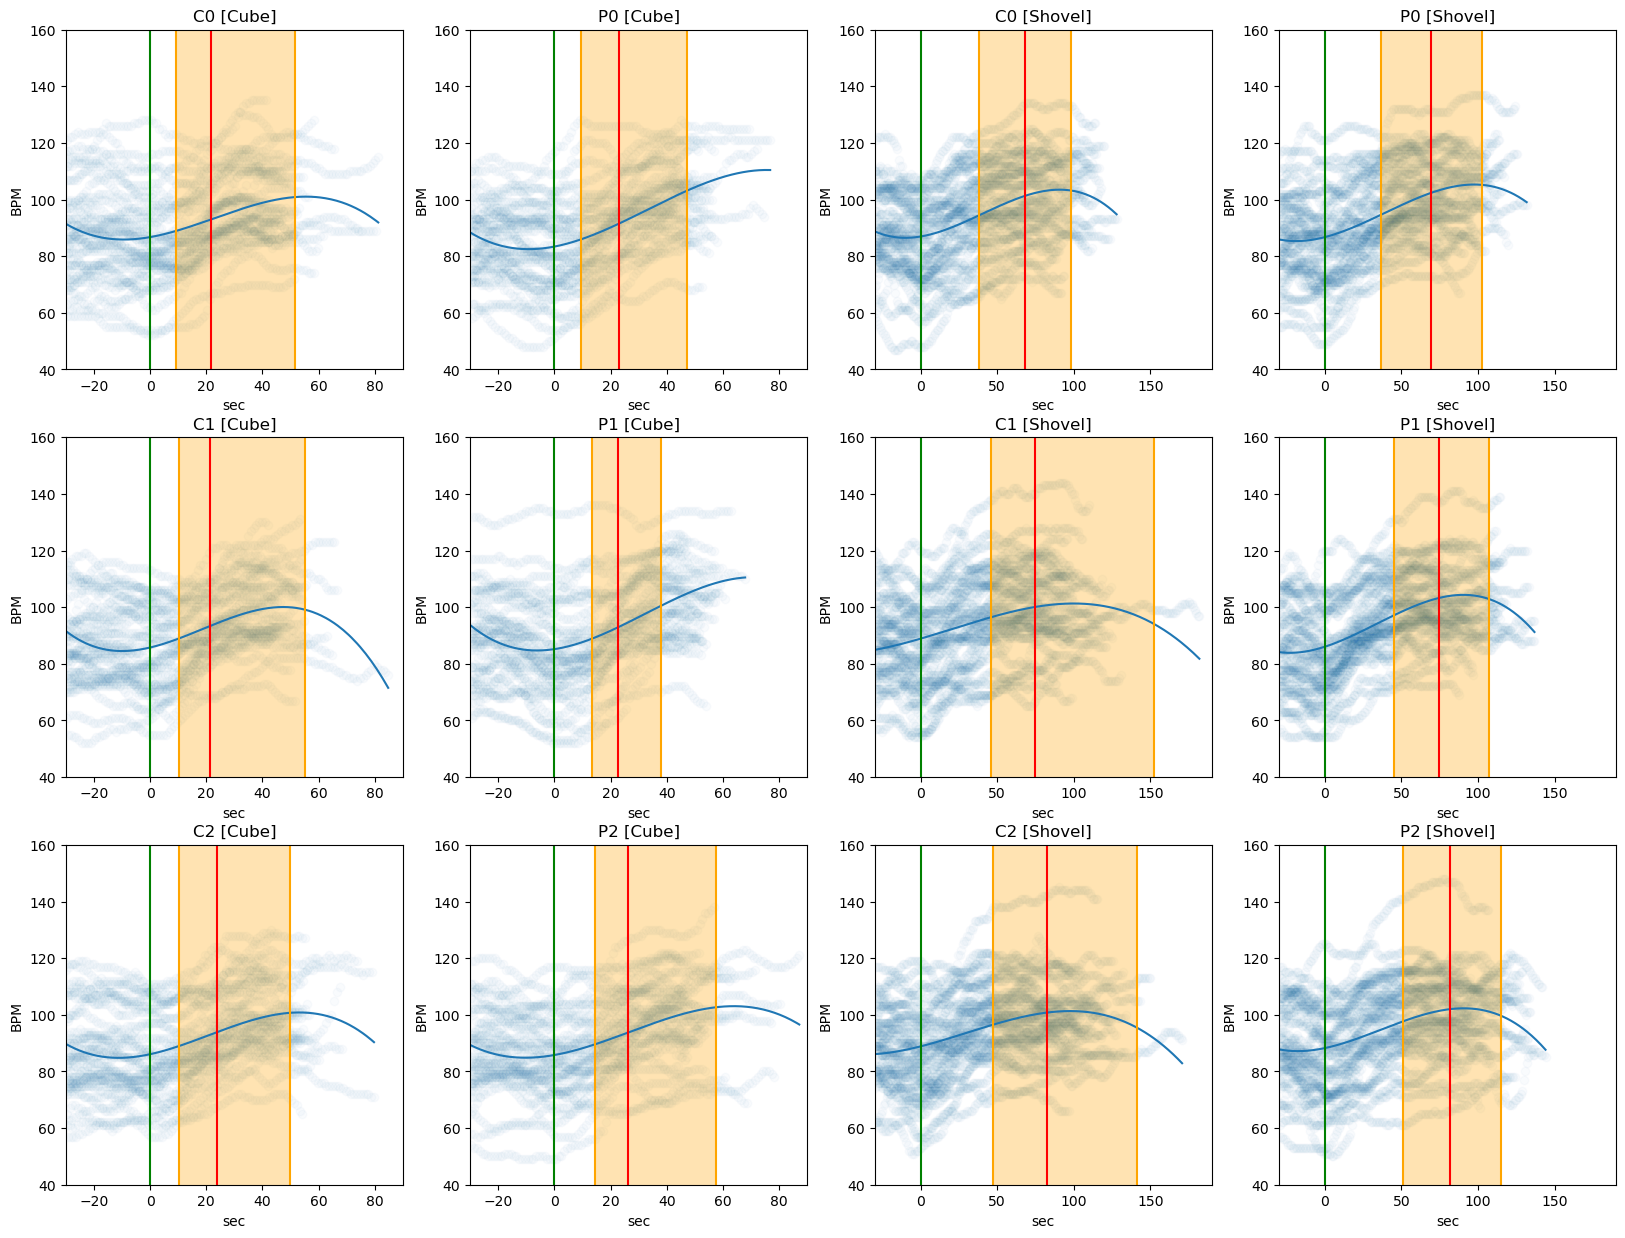

In [13]:
fig, axs = plt.subplots(3, 4, figsize=(20, 15))

ylim = [40,160]

agg_curve(data, axs[0,0], cube, c_0, hr_key, ylim)
agg_curve(data, axs[1,0], cube, c_1, hr_key, ylim)
agg_curve(data, axs[2,0], cube, c_2, hr_key, ylim)
agg_curve(data, axs[0,1], cube, p_0, hr_key, ylim)
agg_curve(data, axs[1,1], cube, p_1, hr_key, ylim)
agg_curve(data, axs[2,1], cube, p_2, hr_key, ylim)

agg_curve(data, axs[0,2], shovel, c_0, hr_key, ylim)
agg_curve(data, axs[1,2], shovel, c_1, hr_key, ylim)
agg_curve(data, axs[2,2], shovel, c_2, hr_key, ylim)
agg_curve(data, axs[0,3], shovel, p_0, hr_key, ylim)
agg_curve(data, axs[1,3], shovel, p_1, hr_key, ylim)
agg_curve(data, axs[2,3], shovel, p_2, hr_key, ylim)

plt.show()

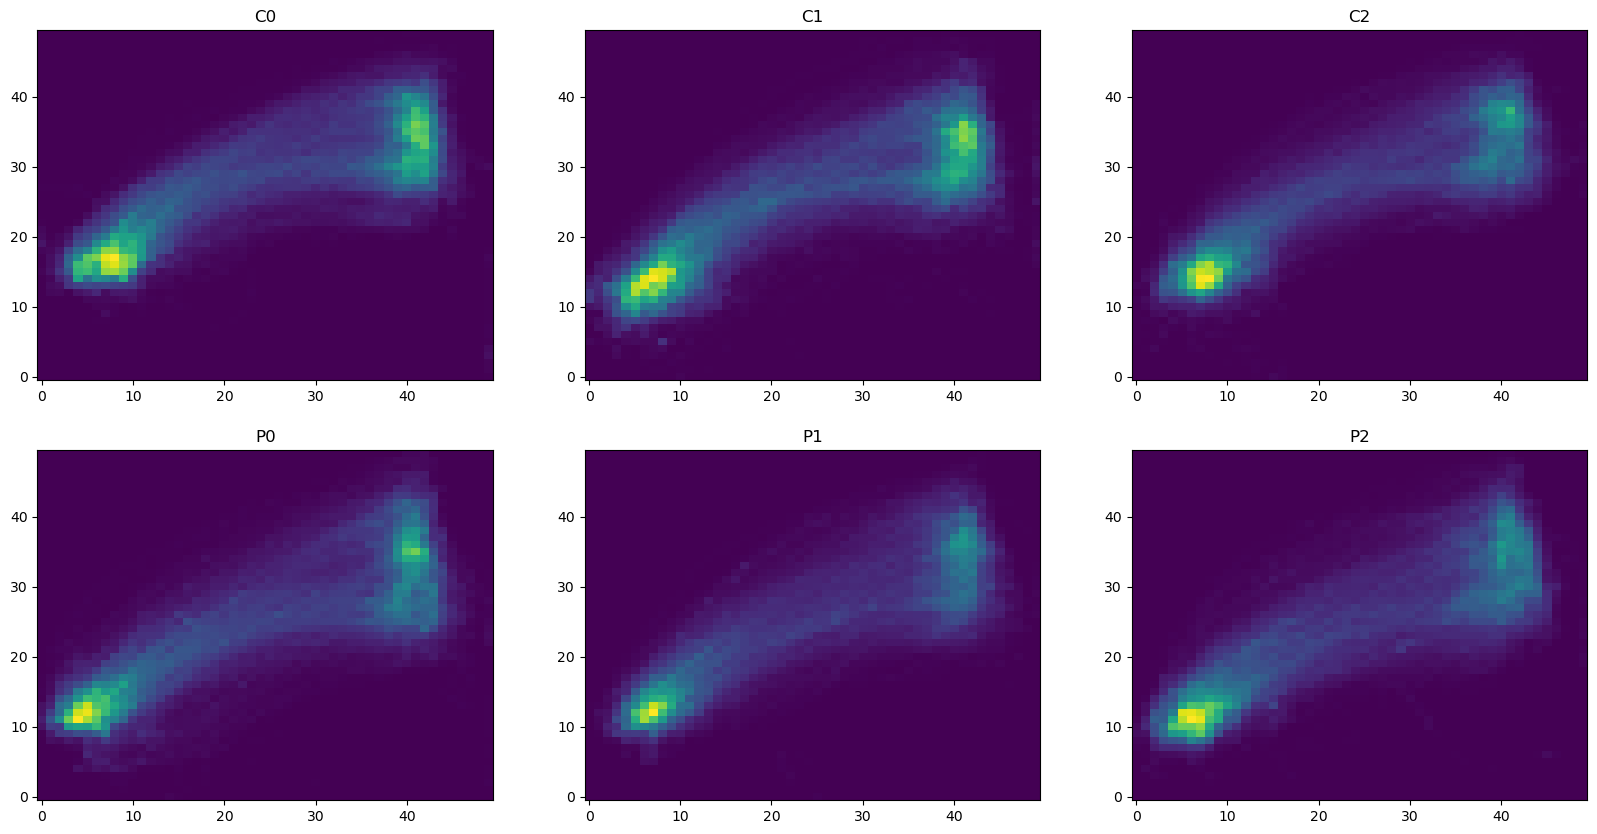

In [14]:
end_effector = 'ee'
primary_tracked = 'pt'
primary_visible = 'pv'
secondary_tracked = 'st'
secondary_visible = 'sv'
hmd = 'hmd'

tracking_pts = [end_effector, primary_tracked, primary_visible, secondary_tracked, secondary_visible, hmd]

def mirror_x(df, pt):
    key = pt + '_x'
    df[key] = df.apply(lambda x: -x[key] if x['primary_grab_hand'] == 'Left' else x[key], axis = 1)

def rectify_unity (p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    for pt in tracking_pts:
        mirror_x(df, pt)

    return df

def top_heatmap(data, ax, e, c, pt):
    participants = list(map(lambda x: x[e][c], data))

    dfs = list(map(lambda x: rectify_unity(x), participants))
    all_values = pd.concat(dfs).sort_values(by=unified_delta_key)

    max_x = 0.25
    min_x = -1.75

    x = np.clip(list(all_values[pt + "_x"]), min_x, max_x)
    y = list(all_values[pt + "_z"])
    z = list(all_values[pt + "_y"])

    heatmap, xedges, yedges = np.histogram2d(x, y, bins=50)

    ax.title.set_text(c)
    ax.imshow(heatmap.T, origin='lower', cmap='viridis', aspect='auto')

    # ax.scatter(x, y, alpha=0.01, s=5)

    # ax.set_xlim([-1.75,0.25])
    # ax.set_ylim([-0.25,1.75])

    # ax.title.set_text(c)
    
    # ax.set_xlabel('X [m]')
    # ax.set_ylabel('Z [m]')


fig, axs = plt.subplots(2, 3, figsize=(20, 10))

shovel_tip = 'ee'
secondary_hand = 'st'
primary_hand = 'pt'

top_heatmap(data, axs[0,0], shovel, c_0, shovel_tip)
top_heatmap(data, axs[0,1], shovel, c_1, shovel_tip)
top_heatmap(data, axs[0,2], shovel, c_2, shovel_tip)
top_heatmap(data, axs[1,0], shovel, p_0, shovel_tip)
top_heatmap(data, axs[1,1], shovel, p_1, shovel_tip)
top_heatmap(data, axs[1,2], shovel, p_2, shovel_tip)

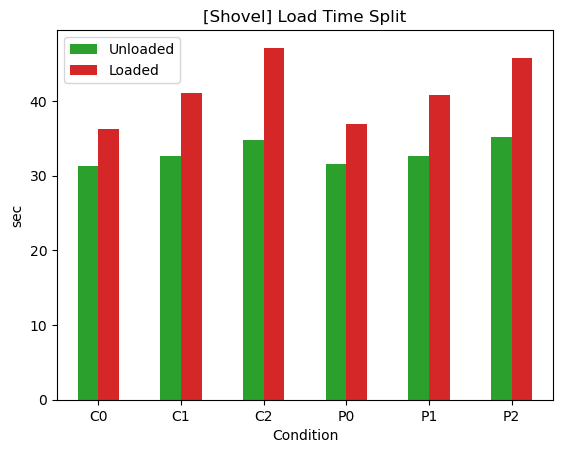

In [15]:
def single_load_time_split (p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    loaded_time = 0
    unloaded_time = 0

    for i in range(20):
        single = df[(df["collision_or_load_count"] == i+1)]

        unloaded = single[(single["shovel_loaded_state"] == False)]
        unloaded_time += unloaded[unity_unix_key].max() - unloaded[unity_unix_key].min()

        loaded = single[(single["shovel_loaded_state"] == True)]
        loaded_time += loaded[unity_unix_key].max() - loaded[unity_unix_key].min()
    
    return [unloaded_time / 1_000, loaded_time / 1_000]

def agg_load_time_split(data, c):
    participants = list(map(lambda x: x[shovel][c], data))

    splits = list(map(lambda x: single_load_time_split(x), participants))
    
    unloaded_times = list(map(lambda x: x[0], splits))
    loaded_times = list(map(lambda x: x[1], splits))
    
    return [np.mean(unloaded_times), np.mean(loaded_times)]

condition_splits = list(map(lambda x: agg_load_time_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["Unloaded", "Loaded"], index = conditions)

df.plot(kind='bar', color=["tab:green", "tab:red"])

plt.title("[Shovel] Load Time Split")
plt.xlabel("Condition")
plt.ylabel("sec")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

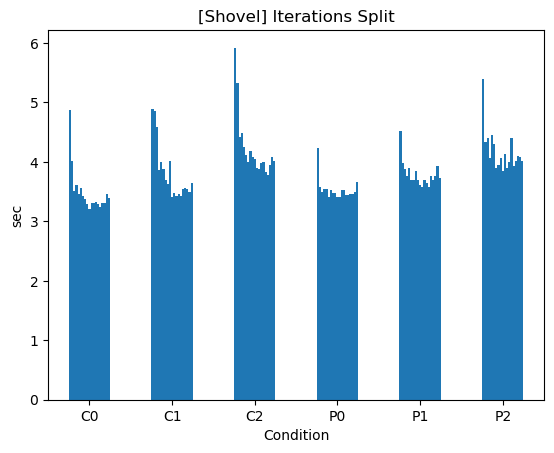

In [16]:
n_iterations = range(19)

def single_iteration_split (p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    iteration_times = []

    for i in n_iterations:
        iteration = df[(df["collision_or_load_count"] == i+1)]
        time = (iteration[unity_unix_key].max() - iteration[unity_unix_key].min() ) / 1_000
        iteration_times.append(time)
    
    return iteration_times

def agg_iteration_split(data, c):
    participants = list(map(lambda x: x[shovel][c], data))

    participant_splits = list(map(lambda x: single_iteration_split(x), participants))
    n_participants = len(participants)

    splits = []

    for i in n_iterations:
        splits.append([])
        for j in range(n_participants):
            splits[i].append(participant_splits[j][i])

    split_means = list(map(lambda x: np.mean(x), splits))
    
    return split_means

condition_splits = list(map(lambda x: agg_iteration_split(data, x), conditions))

columns = list(map(lambda x: str(x+1), n_iterations))

df = pd.DataFrame(condition_splits, columns=columns, index = conditions)

df.plot(kind='bar', color = "tab:blue", legend=False)

plt.title("[Shovel] Iterations Split")
plt.xlabel("Condition")
plt.ylabel("sec")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

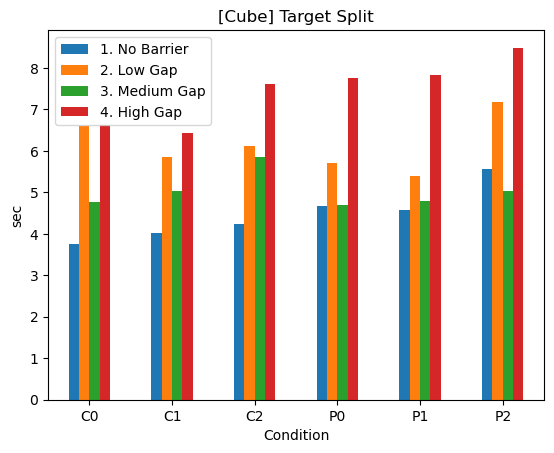

In [17]:
def single_target_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_time = first[unified_unix_key].max() - first[unified_unix_key].min()
    second_time = second[unified_unix_key].max() - second[unified_unix_key].min()
    third_time = third[unified_unix_key].max() - third[unified_unix_key].min()
    fourth_time = fourth[unified_unix_key].max() - fourth[unified_unix_key].min()

    return [first_time / 1_000, second_time / 1_000, third_time / 1_000, fourth_time / 1_000]

def agg_target_split(data, c):
    participants = list(map(lambda x: x[cube][c], data))

    splits = list(map(lambda x: single_target_split(x), participants))
    
    first = list(map(lambda x: x[0],  splits))
    second = list(map(lambda x: x[1], splits))
    third = list(map(lambda x: x[2],  splits))
    fourth = list(map(lambda x: x[3], splits))
    
    return [np.mean(first), np.mean(second), np.mean(third), np.mean(fourth)]

condition_splits = list(map(lambda x: agg_target_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["1. No Barrier", "2. Low Gap", "3. Medium Gap", "4. High Gap"], index = conditions)

df.plot(kind='bar', color=["tab:blue", "tab:orange", "tab:green", "tab:red"])

plt.title("[Cube] Target Split")
plt.xlabel("Condition")
plt.ylabel("sec")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

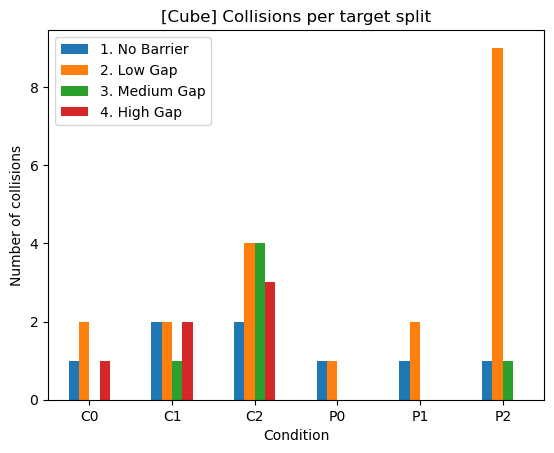

In [18]:
def single_collision_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_collisons =first["collision_or_load_count"].max() - first["collision_or_load_count"].min()
    second_collisons =second["collision_or_load_count"].max() - second["collision_or_load_count"].min()
    third_collisons =third["collision_or_load_count"].max() - third["collision_or_load_count"].min()
    fourth_collisons =fourth["collision_or_load_count"].max() - fourth["collision_or_load_count"].min()

    return [first_collisons, second_collisons, third_collisons, fourth_collisons]

def agg_collision_split(data, c):
    participants = list(map(lambda x: x[cube][c], data))

    splits = list(map(lambda x: single_collision_split(x), participants))
    
    first = list(map(lambda x: x[0],  splits))
    second = list(map(lambda x: x[1], splits))
    third = list(map(lambda x: x[2],  splits))
    fourth = list(map(lambda x: x[3], splits))
    
    return [np.sum(first), np.sum(second), np.sum(third), np.sum(fourth)]

condition_splits = list(map(lambda x: agg_collision_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["1. No Barrier", "2. Low Gap", "3. Medium Gap", "4. High Gap"], index = conditions)

df.plot(kind='bar', color=["tab:blue", "tab:orange", "tab:green", "tab:red"])

plt.title("[Cube] Collisions per target split")
plt.xlabel("Condition")
plt.ylabel("Number of collisions")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

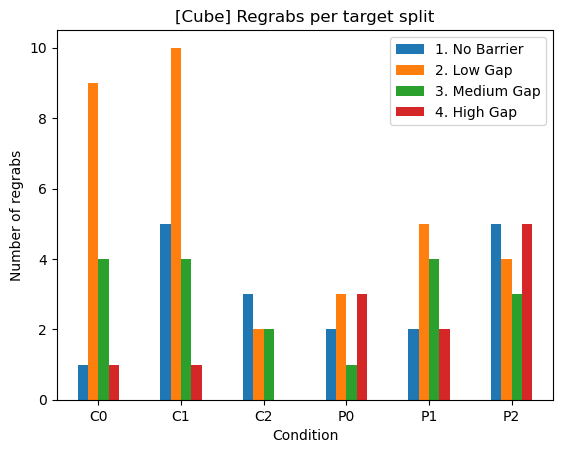

In [19]:
def single_grabcount_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_regrabs =first["grab_count"].max() - first["grab_count"].min()
    second_regrabs =second["grab_count"].max() - second["grab_count"].min()
    third_regrabs =third["grab_count"].max() - third["grab_count"].min()
    fourth_regrabs =fourth["grab_count"].max() - fourth["grab_count"].min()

    return [first_regrabs, second_regrabs, third_regrabs, fourth_regrabs]

def agg_grabcount_split(data, c):
    participants = list(map(lambda x: x[cube][c], data))

    splits = list(map(lambda x: single_grabcount_split(x), participants))
    
    first = list(map(lambda x: x[0],  splits))
    second = list(map(lambda x: x[1], splits))
    third = list(map(lambda x: x[2],  splits))
    fourth = list(map(lambda x: x[3], splits))
    
    return [np.sum(first), np.sum(second), np.sum(third), np.sum(fourth)]

condition_splits = list(map(lambda x: agg_grabcount_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["1. No Barrier", "2. Low Gap", "3. Medium Gap", "4. High Gap"], index = conditions)

df.plot(kind='bar', color=["tab:blue", "tab:orange", "tab:green", "tab:red"])

plt.title("[Cube] Regrabs per target split")
plt.xlabel("Condition")
plt.ylabel("Number of regrabs")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

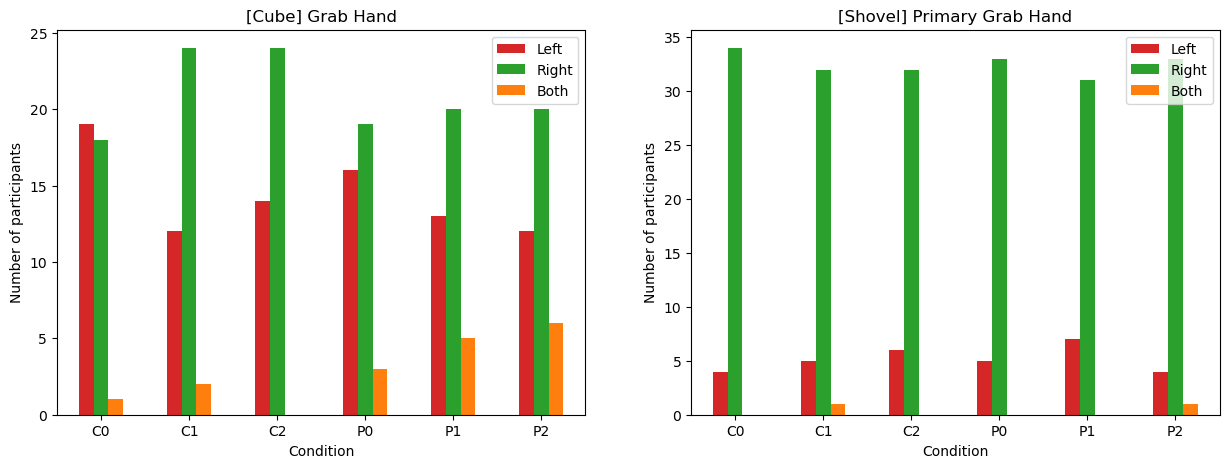

In [20]:
primary_left = "Left"
primary_right = "Right"
primary_both = "Both"
primary_none = "None"

primary_options = [primary_left, primary_right, primary_both]

def single_primary_hand(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    left = (df['primary_grab_hand'] == primary_left).any()
    right = (df['primary_grab_hand'] == primary_right).any()

    if left & right:
        return primary_both
    elif left:
        return primary_left
    elif right:
        return primary_right
    else:
        return primary_none

def agg_primary_hand(data, e, c):
    participants = list(map(lambda x: x[e][c], data))

    participant_hands = list(map(lambda x: single_primary_hand(x), participants))

    left = 0
    right = 0
    both = 0
    none = 0

    for i in range(len(participant_hands)):
        hands = participant_hands[i]

        if hands == primary_left:
            left += 1
        elif hands == primary_right:
            right += 1
        elif hands == primary_both:
            both += 1
        elif hands == primary_none:
            none += 1
    
    return [left, right, both]

cube_hands = list(map(lambda x: agg_primary_hand(data, cube, x), conditions))
cube_hands_df = pd.DataFrame(cube_hands, columns=primary_options, index = conditions)

shovel_hands = list(map(lambda x: agg_primary_hand(data, shovel, x), conditions))
shovel_hands_df = pd.DataFrame(shovel_hands, columns=primary_options, index = conditions)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cube_hands_df.plot(kind='bar', color=["tab:red", "tab:green", "tab:orange"], ax=axs[0])
axs[0].set_title('[Cube] Grab Hand')
axs[0].set_xlabel('Condition')
axs[0].set_ylabel('Number of participants')
axs[0].xaxis.set_tick_params(rotation=0)

shovel_hands_df.plot(kind='bar', color=["tab:red", "tab:green", "tab:orange"], ax=axs[1])
axs[1].set_title('[Shovel] Primary Grab Hand')
axs[1].set_xlabel('Condition')
axs[1].set_ylabel('Number of participants')
axs[1].xaxis.set_tick_params(rotation=0)

plt.show()